
#Drowsiness Detection using CNN
#Author: Nafiu Ikeoluwa HAMMED
Date: December, 2025


#0. Setup & Configuration

#– Imports & basic info

In [ ]:
import os
import cv2
import imghdr
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Rescaling
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

print("TensorFlow version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)


/tmp/ipython-input-1222558337.py:3: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


TensorFlow version: 2.19.0
GPU Available: True


#– GPU memory growth

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
gpus


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# – Global config

In [ ]:
DATA_DIR = '/content/drive/MyDrive/Data'
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 123


#1. Clean / Remove Dodgy Images

#– Remove corrupted images

In [ ]:
image_exts = ['jpeg', 'jpg', 'bmp', 'png']

num_removed = 0
for image_class in os.listdir(DATA_DIR):
    class_dir = os.path.join(DATA_DIR, image_class)
    if not os.path.isdir(class_dir):
        continue

    for image_name in os.listdir(class_dir):
        image_path = os.path.join(class_dir, image_name)

        # Skip non-files
        if not os.path.isfile(image_path):
            continue

        # Check extension
        ext = image_name.split('.')[-1].lower()
        if ext not in image_exts:
            print(f"Removing (bad ext): {image_path}")
            os.remove(image_path)
            num_removed += 1
            continue

        # Check if image is readable
        try:
            img_type = imghdr.what(image_path)
            if img_type not in image_exts:
                print(f"Removing (imghdr bad): {image_path}")
                os.remove(image_path)
                num_removed += 1
        except Exception as e:
            print(f"Removing (read error): {image_path}, error={e}")
            os.remove(image_path)
            num_removed += 1

print(f"Total removed suspicious images: {num_removed}")


#2. Load Data with image_dataset_from_directory

#– Create dataset

In [ ]:
data = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)


Found 41832 files belonging to 2 classes.


#– Normalize & cache/prefetch

In [ ]:
def prepare_ds(ds):
    # normalize to [0,1] and add performance optimizations
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))
    return ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

data = prepare_ds(data)


#– Visualize a sample batch

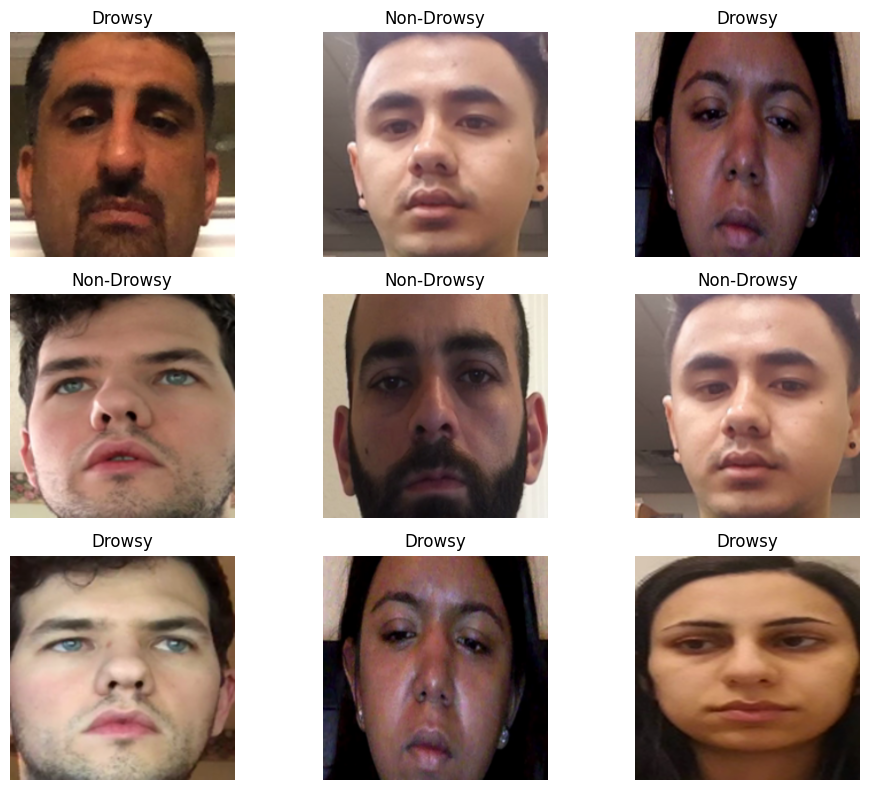

In [ ]:
batch_images, batch_labels = next(iter(data))

plt.figure(figsize=(10, 8))
for i in range(9):
    img = batch_images[i].numpy()
    label = int(batch_labels[i].numpy().squeeze())
    label_name = "Non-Drowsy" if label == 1 else "Drowsy"
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(label_name)
plt.tight_layout()
plt.show()


#3. Split into Train / Val / Test

#– Split

In [ ]:
import tensorflow as tf

dataset_size = tf.data.experimental.cardinality(data).numpy()
print("Total batches in full dataset:", dataset_size)

train_size = int(dataset_size * 0.7)
val_size   = int(dataset_size * 0.2)
test_size  = dataset_size - train_size - val_size

print(f"Train: {train_size}, Val: {val_size}, Test: {test_size}")

train_ds = data.take(train_size)
remaining = data.skip(train_size)

val_ds   = remaining.take(val_size)
test_ds  = remaining.skip(val_size)

print("Cardinalities after split:")
print("  Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("  Val batches:  ", tf.data.experimental.cardinality(val_ds).numpy())
print("  Test batches: ", tf.data.experimental.cardinality(test_ds).numpy())



Total batches in full dataset: 1308
Train: 915, Val: 261, Test: 132
Cardinalities after split:
  Train batches: 915
  Val batches:   261
  Test batches:  132


#4. Define 3 Model Variants

Comparing three model combinations:

*   Model A – Baseline
*   Model B – Deeper filters + Dropout.
*   Model C – Even deeper + more Dropout.



#– Model factory

In [ ]:
def build_cnn_model(variant="A", input_shape=(256, 256, 3)):
    model = Sequential()

    if variant == "A":  # Baseline
        model.add(Conv2D(16, (3,3), activation='relu', input_shape=input_shape))
        model.add(MaxPooling2D())

        model.add(Conv2D(32, (3,3), activation='relu'))
        model.add(MaxPooling2D())

        model.add(Conv2D(16, (3,3), activation='relu'))
        model.add(MaxPooling2D())

        model.add(Flatten())
        model.add(Dense(256, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))

    elif variant == "B":  # More filters + dropout
        model.add(Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
        model.add(MaxPooling2D())

        model.add(Conv2D(64, (3,3), activation='relu'))
        model.add(MaxPooling2D())

        model.add(Conv2D(32, (3,3), activation='relu'))
        model.add(MaxPooling2D())

        model.add(Flatten())
        model.add(Dense(256, activation='relu'))
        model.add(Dropout(0.5))
        model.add(Dense(1, activation='sigmoid'))

    elif variant == "C":  # Deeper + more Dropout
        model.add(Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
        model.add(MaxPooling2D())

        model.add(Conv2D(64, (3,3), activation='relu'))
        model.add(MaxPooling2D())

        model.add(Conv2D(64, (3,3), activation='relu'))
        model.add(MaxPooling2D())

        model.add(Flatten())
        model.add(Dense(512, activation='relu'))
        model.add(Dropout(0.5))
        model.add(Dense(1, activation='sigmoid'))

    else:
        raise ValueError("Unknown variant")

    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=['accuracy']
    )
    return model


#5. Train and Compare the 3 Models

#– Train all variants

In [ ]:
logdir_root = "logs"
histories = {}
models_dict = {}
variants = ["A", "B", "C"]

for v in variants:
    print(f"\n===== Training Model {v} =====")
    model = build_cnn_model(variant=v, input_shape=IMG_SIZE + (3,))
    model.summary()

    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=os.path.join(logdir_root, f"model_{v}")
    )

    hist = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        callbacks=[tensorboard_callback],
        verbose=1
    )

    histories[v] = hist
    models_dict[v] = model



===== Training Model A =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    29,491,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,548,545 (112.72 MB)

 Trainable params: 29,548,545 (112.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
915/915 ━━━━━━━━━━━━━━━━━━━━ 119s 125ms/step - accuracy: 0.9113 - loss: 0.2030 - val_accuracy: 0.9959 - val_loss: 0.0130
Epoch 2/20
915/915 ━━━━━━━━━━━━━━━━━━━━ 114s 124ms/step - accuracy: 0.9962 - loss: 0.0151 - val_accuracy: 0.9988 - val_loss: 0.0042
Epoch 3/20
915/915 ━━━━━━━━━━━━━━━━━━━━ 114s 125ms/step - accuracy: 0.9996 - loss: 0.0019 - val_accuracy: 0.9974 - val_loss: 0.0076
Epoch 4/20
915/915 ━━━━━━━━━━━━━━━━━━━━ 113s 124ms/step - accuracy: 0.9973 - loss: 0.0110 - val_accuracy: 0.9990 - val_loss: 0.0023
Epoch 5/20
915/915 ━━━━━━━━━━━━━━━━━━━━ 114s 125ms/step - accuracy: 0.9985 - loss: 0.0073 - val_accuracy: 0.9996 - val_loss: 0.0011
Epoch 6/20
915/915 ━━━━━━━━━━━━━━━━━━━━ 114s 124ms/step - accuracy: 0.9993 - loss: 0.0042 - val_accuracy: 0.9972 - val_loss: 0.0188
Epoch 7/20
915/915 ━━━━━━━━━━━━━━━━━━━━ 113s 124ms/step - accuracy: 0.9986 - loss: 0.0073 - val_accuracy: 0.9994 - val_loss: 0.0017
Epoch 8/20
915/915 ━━━━━━━━━━━━━━━━━━━━ 114s 125ms/step - accuracy: 0.9997 -

#6. Nice Charts: Training vs Validation Curves

#– Plot loss and accuracy for each model

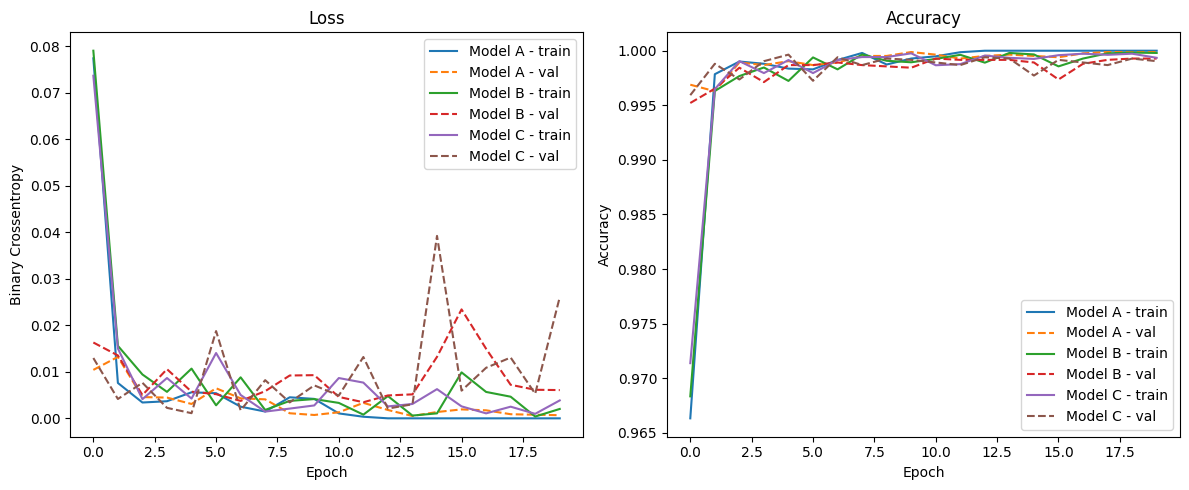

In [ ]:
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
for v in variants:
    hist = histories[v].history
    plt.plot(hist['loss'], label=f'Model {v} - train')
    plt.plot(hist['val_loss'], linestyle='--', label=f'Model {v} - val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
for v in variants:
    hist = histories[v].history
    plt.plot(hist['accuracy'], label=f'Model {v} - train')
    plt.plot(hist['val_accuracy'], linestyle='--', label=f'Model {v} - val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


#– Pick the best model by validation accuracy

In [ ]:
best_variant = None
best_val_acc = -1.0

for v in variants:
    val_acc = max(histories[v].history['val_accuracy'])
    print(f"Model {v}: best val_accuracy = {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_variant = v

print(f"\n>>> Best model is Variant {best_variant} with val_accuracy={best_val_acc:.4f}")
best_model = models_dict[best_variant]


Model A: best val_accuracy = 0.9999
Model B: best val_accuracy = 0.9993
Model C: best val_accuracy = 0.9996

>>> Best model is Variant A with val_accuracy=0.9999


#7. Evaluate Best Model on Test Data

#– Precision, Recall, Accuracy on test

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

pre = Precision()
re  = Recall()
acc = BinaryAccuracy()

for batch_x, batch_y in test_ds:
    # No progress bar, just a forward pass
    yhat = best_model(batch_x, training=False)

    pre.update_state(batch_y, yhat)
    re.update_state(batch_y, yhat)
    acc.update_state(batch_y, yhat)

print(f"Test Precision: {pre.result().numpy():.4f}")
print(f"Test Recall:    {re.result().numpy():.4f}")
print(f"Test Accuracy:  {acc.result().numpy():.4f}")



Test Precision: 0.9995
Test Recall:    0.9989
Test Accuracy:  0.9993


#– Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

for batch_x, batch_y in test_ds:
    # Progress
    yhat = best_model(batch_x, training=False).numpy().ravel()

    y_true.extend(batch_y.numpy().astype(int).ravel())
    y_pred.extend((yhat > 0.5).astype(int).ravel())

cm = confusion_matrix(y_true, y_pred)
cm


array([[2295,    1],
       [   2, 1902]])

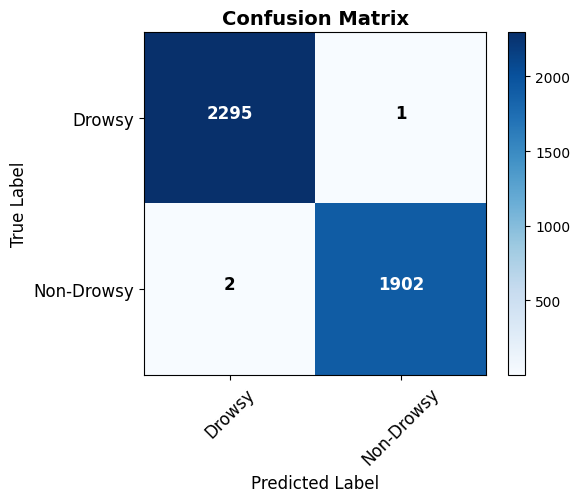

In [ ]:
def plot_confusion_matrix(cm, classes=('Drowsy', 'Non-Drowsy')):
    plt.figure(figsize=(6,5))

    # Beautiful color map
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

    plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=12)
    plt.yticks(tick_marks, classes, fontsize=12)

    # Text contrast
    thresh = cm.max() / 2.0

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j, i, format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=12,
            fontweight='bold'
        )

    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm)



#8. Save the Best Model

In [ ]:
MODEL_PATH = "drowsiness_cnn_best.h5"
best_model.save(MODEL_PATH)
print("Saved best model as:", MODEL_PATH)


Saved best model as: drowsiness_cnn_best.h5


#9. Test on Unseen Images (4 at once)

#– Helper function

In [ ]:
def predict_on_images(model, image_paths, img_size=IMG_SIZE, threshold=0.5):
    imgs = []
    for p in image_paths:
        img = cv2.imread(p)
        if img is None:
            raise ValueError(f"Could not read image: {p}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, img_size)
        imgs.append(img_resized)

    batch = np.array(imgs, dtype=np.float32) / 255.0  # shape (N, H, W, 3)
    yhat_batch = model.predict(batch)
    yhat_batch = np.squeeze(yhat_batch)

    # Print predictions
    for p, score in zip(image_paths, yhat_batch):
        label = "Drowsy" if score > threshold else "Non-Drowsy"
        print(f"{p} -> {label} (score={score:.4f})")

    # Plot grid
    n = len(image_paths)
    rows = 2
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(12, 6))
    for i, (p, score) in enumerate(zip(image_paths, yhat_batch)):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis("off")
        label = "Drowsy" if score > threshold else "Non-Drowsy"
        plt.title(f"{label}\nscore={score:.2f}")
    plt.tight_layout()
    plt.show()


#– Call it on 4 unseen images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
/content/drive/MyDrive/NT/ND0001.jpeg -> Non-Drowsy (score=0.0000)
/content/drive/MyDrive/NT/ND0002.jpeg -> Non-Drowsy (score=0.0000)
/content/drive/MyDrive/T/DO0001.jpeg -> Drowsy (score=0.9802)
/content/drive/MyDrive/T/DO0002.jpg -> Drowsy (score=0.9999)


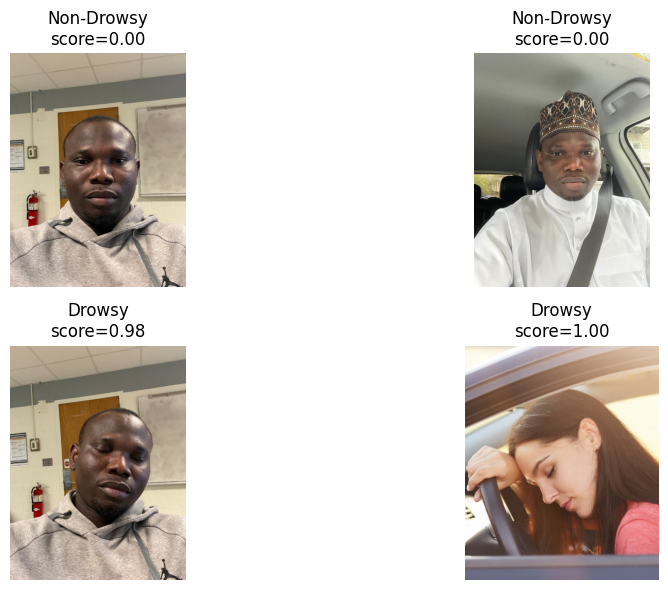

In [ ]:
image_paths = [
    "/content/drive/MyDrive/NT/ND0001.jpeg",
    "/content/drive/MyDrive/NT/ND0002.jpeg",
    "/content/drive/MyDrive/T/DO0001.jpeg",
    "/content/drive/MyDrive/T/DO0002.jpg",
]

predict_on_images(best_model, image_paths)
